In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
import plotly.graph_objects as go

In [2]:
#Importing all the datasets first: 
df_l_grbsn = pd.read_csv("l_grbsn.csv")
df_z_grbsn = pd.read_csv("z_grb_sne.csv")
df_selected = pd.read_csv("L_iso_pwr_selected.csv")
df_l_Ic_bl = pd.read_csv("Ic-BL Lum.csv")
df_z_Ic_bl = pd.read_csv("Ic-BL Red.csv")
df_l_list = pd.read_csv("l_iso_list.csv")
df_redshifts = pd.read_csv("redshifts.csv")
df_best_sample_sn = pd.read_csv("best_sample_sn.csv")
df_best_sample_lgrb = pd.read_csv("best_sample_log_L_GRB_blue.csv")
df_best_sample_zgrb = pd.read_csv("best_sample_log_z_blue.csv")

In [3]:
l_grb_sne = df_l_grbsn['0'] 
l_grb_sne = np.array(l_grb_sne, dtype = np.float64) #→ SN Luminosity (X-axis)

L_iso_pwr_selected = df_selected['0']
L_iso_pwr_selected = np.array(L_iso_pwr_selected, dtype = np.float64)

z_grb_sne = df_z_grbsn['0']
z_grb_sne = np.array(z_grb_sne, dtype = np.float64)

l_Ic_bl = df_l_Ic_bl['0']
l_Ic_bl = np.array(l_Ic_bl, dtype = np.float64)

z_Ic_bl = df_z_Ic_bl['Unnamed: 1']
z_Ic_bl_clean = [float(str(entry).split(',')[0]) for entry in z_Ic_bl]
z_Ic_bl = z_Ic_bl_clean
z_Ic_bl = np.array(z_Ic_bl, dtype = np.float64)

L_iso_list = df_l_list['0']
L_iso_list = np.array(L_iso_list, dtype = np.float64)

redshifts = df_redshifts['0']
redshifts = np.array(redshifts, dtype = np.float64)

best_sample_sn_1 = df_best_sample_sn['0']
best_sample_sn_1 = np.array(best_sample_sn_1, dtype = np.float64)

best_sample_log_L_GRB_blue = df_best_sample_lgrb['0']
best_sample_log_L_GRB_blue = np.array(best_sample_log_L_GRB_blue, dtype = np.float64)

best_sample_log_z_blue = df_best_sample_zgrb['0']
best_sample_log_z_blue = np.array(best_sample_log_z_blue, dtype = np.float64)

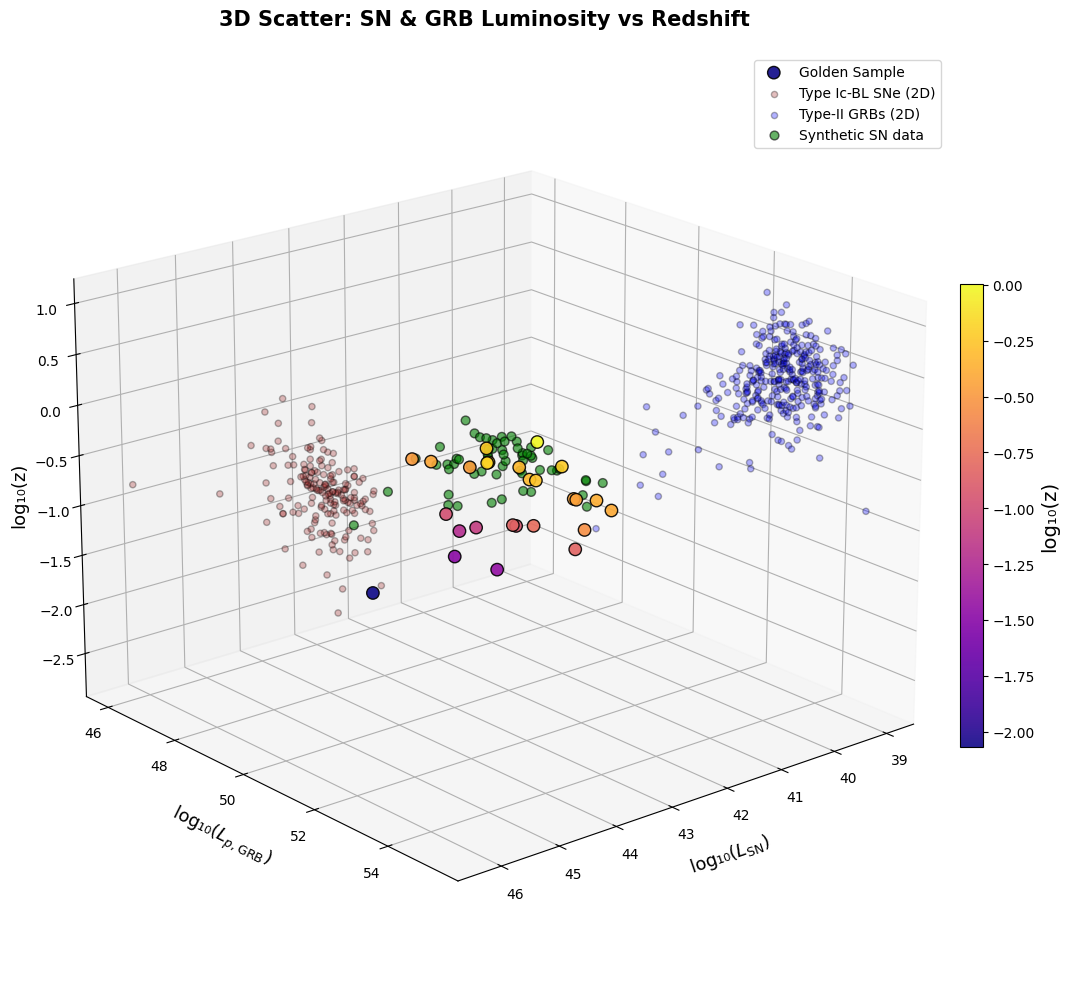

In [4]:
# Arrays you already have:
# l_grb_sne → SN Luminosity (X-axis)
# L_iso_pwr_selected → GRB Luminosity (Z-axis)
# z_grb_sne → Redshift (Y-axis)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# 3D Scatter Plot
scatter = ax.scatter(
    np.log10(l_grb_sne),
    np.log10(L_iso_pwr_selected),
    np.log10(z_grb_sne),
    c=np.log10(z_grb_sne),          # Color by redshift
    cmap='plasma',                  # Scientific colormap
    s=80,                           # Size of points
    alpha=0.9,
    edgecolor='black',
    label = 'Golden Sample'
)

#ax.scatter(
  # np.log10(np.full_like(z_grb, 1e39)),            # X = 0 → projecting into SN Lum = 0 plane
  # np.log10(L_iso_pwr),                            # Y = GRB Luminosity
  # np.log10(z_grb),                                # Z = redshift
  # color='green',
  # s = 20,
  # alpha=0.4,
  # edgecolor='black',
  # label='SN-GRB (2D)'
#)

ax.scatter(
   np.log10(l_Ic_bl),                                 # X = SNe Luminosity 
   np.log10(np.full_like(z_Ic_bl, 1e46)),             # Y = 0 → projecting into GRB Lum = 0 plane
   np.log10(z_Ic_bl),                                 # Z = redshift
   color='brown',
   s = 20,
   alpha=0.3,
   edgecolor='black',
   label='Type Ic-BL SNe (2D)'
)

ax.scatter(
   np.log10(np.full_like(redshifts, 1e39)),  # X = 0 → projecting into SN Lum = 0 plane
   np.log10(L_iso_list),                     # Y = GRB Luminosity
   np.log10(redshifts),                      # Z = redshift
   color='blue',
   s = 20,
   alpha=0.3,
   edgecolor='black',
   label='Type-II GRBs (2D)'
)


ax.scatter(
  np.log10(best_sample_sn_1),     # X = SN Lum 
  best_sample_log_L_GRB_blue,     # Y = GRB Luminosity
  best_sample_log_z_blue,         # Z = redshift
  color = 'green', 
  s = 40,
  alpha=0.6,
  edgecolor='black',
  label='Synthetic SN data'
)

#ax.scatter(
 # np.log10(l_Ic_bl),                   # X = SN Lum 
 # np.log10(z_Ic_bl),                   # Z = redshift,
  #color = 'maroon', 
  #s = 40,
  #alpha=0.3,
  #edgecolor='black',
  #label='Created GRB data'
#)

# Axis labels
ax.set_xlabel('log₁₀($L_{\mathrm{SN}}$)', fontsize=13, labelpad=10)
ax.set_ylabel('log₁₀($L_{p,\mathrm{GRB}}$)', fontsize=13, labelpad=10)
#ax.set_zlabel('log₁₀(Redshift)', fontsize=13, labelpad = 10)
fig.text(0.05, 0.5, 'log₁₀(z)', va='center', rotation='vertical', fontsize=13)
ax.set_title('3D Scatter: SN & GRB Luminosity vs Redshift', fontsize=15, weight='bold', pad=20)
#ax.set_xscale('log')
#ax.set_ylim(bottom=1e+44)
#ax.set_xscale('log')


# Add color bar for redshift
#cbar_1 = plt.colorbar(scatter_1, ax=ax, shrink=0.5, pad=0.1)
#cbar_1.set_label('log₁₀(Redshift)_1', fontsize=12)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label('log₁₀(z)', fontsize=14)

# Styling
ax.view_init(elev=20, azim= 50)  # Camera angle
#ax.grid(True)

# === Animation function ===
def update(angle):
    ax.view_init(elev=30, azim=angle)  # You can change elev to anything
    return fig,
#
# Create animation: Rotate azimuth from 0° to 360°
#ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 1), interval=200)

# === Save the animation ===
# Option 1: Save as .gif
#ani.save('3D_Create_same.gif', writer=PillowWriter(fps=20))

# Option 2: Save as .mp4 (requires ffmpeg)
#ani.save('3D_Create_same.mp4', writer='ffmpeg', fps=20)

# === Orbiting animation function (elevation + rotation) ===
def update_1(frame):
    azim = frame  # Azimuth goes from 0 to 360
    elev = 20+ 10 * np.sin(np.radians(frame))  # Elevation oscillates
    ax.view_init(elev=elev, azim=azim)
    return fig,

# Animate over full 360 degrees
#ani = FuncAnimation(fig, update_1, frames=np.arange(0, 360, 1), interval=200)

# === Save as a GIF ===
#ani.save('3D_Create.gif', writer=PillowWriter(fps=20))

# Option 2: Save as .mp4 (requires ffmpeg)
#ani.save('3D_Create.mp4', writer='ffmpeg', fps=20)

plt.tight_layout()
plt.legend()
#plt.subplots_adjust(left=0.15, right=0.9, bottom=0.1, top=0.9)
plt.savefig('3-D Luminosity Plot upd', bbox_inches = 'tight',transparent = False, facecolor = 'white')
plt.show()

In [5]:
# Your existing arrays:
# l_grb_sne → SN Luminosity (X-axis)
# L_iso_pwr_selected → GRB Luminosity (Z-axis)
# z_grb_sne → Redshift (Y-axis)
# plus: z_grb, L_iso_pwr, l_Ic_bl, z_Ic_bl, redshifts, L_iso_list, best_sample_sn_1, best_sample_log_L_GRB_blue, best_sample_log_z_blue

fig = go.Figure()

# 3D scatter: Golden Sample
fig.add_trace(go.Scatter3d(
    x=np.log10(l_grb_sne),
    y=np.log10(L_iso_pwr_selected),
    z=np.log10(z_grb_sne),
    mode='markers',
    marker=dict(
        size=6,
        color=np.log10(z_grb_sne),
        colorscale='Plasma',
        opacity=0.9,
        line=dict(width=1, color='black')
    ),
    name='Golden Sample'
))

# SN-GRBs (2D projection)
#fig.add_trace(go.Scatter3d(
 #   x=np.log10(np.full_like(z_grb, 1e39)),
  #  y=np.log10(L_iso_pwr),
   # z=np.log10(z_grb),
    #mode='markers',
    #marker=dict(color='green', size=4, opacity=0.3, line=dict(width=1, color='black')),
    #name='SN-GRB (2D)'
#))

# Type Ic-BL
fig.add_trace(go.Scatter3d(
    x=np.log10(l_Ic_bl),
    y=np.log10(np.full_like(z_Ic_bl, 1e46)),
    z=np.log10(z_Ic_bl),
    mode='markers',
    marker=dict(color='brown', size=4, opacity=0.3, line=dict(width=1, color='black')),
    name='Type Ic-BL SNe (2D)'
))

# Type-II GRB
fig.add_trace(go.Scatter3d(
    x=np.log10(np.full_like(redshifts, 1e40)),
    y=np.log10(L_iso_list),
    z=np.log10(redshifts),
    mode='markers',
    marker=dict(color='blue', size=4, opacity=0.3, line=dict(width=1, color='black')),
    name='Type-II GRBs (2D)'
))

# Created SN data
fig.add_trace(go.Scatter3d(
    x=np.log10(best_sample_sn_1),
    y=best_sample_log_L_GRB_blue,
    z=best_sample_log_z_blue,
    mode='markers',
    marker=dict(color='green', size=5, opacity=0.6, line=dict(width=1, color='black')),
    name='Synthetic SN data'
))

# Add colorbar separately (for the first trace)
fig.data[0].marker.showscale = True
fig.data[0].marker.colorbar = dict(title='log₁₀(z)')
# Move the legend farther right and give the colorbar its own lane
fig.update_layout(
    title='3D Scatter: SN & GRB Luminosity vs Redshift',
    scene=dict(
        xaxis_title='log₁₀(L_SN)',
        yaxis_title='log₁₀(L_GRB)',
        zaxis_title='log₁₀(z)'
    ),
    width=1000, height=800,
    #margin=dict(l=80, r=180, t=70, b=70),      # extra right margin
    legend=dict(
     #   x=1,  y=1,                          # push legend right
     #   bgcolor='rgba(255,255,255,0.8)',
     bordercolor='black', borderwidth=1
    )
)

# Nudge the colorbar a bit left of the legend
fig.data[0].marker.colorbar.x = 1.5        # position (0–1); >1 pushes outside plot
fig.data[0].marker.colorbar.y = 0.5           # center vertically
fig.data[0].marker.colorbar.len = 0.5         # shrink length if desired

fig.write_html("sn_grb_luminosity_3d.html", include_plotlyjs="cdn")
fig.show()
